# Model Architecture

The implemented model leverages a Transformer architecture for sentiment analysis. The Transformer block consists of multiple self-attention mechanisms applied iteratively (num_heads). Each attention mechanism captures different aspects of the input sequence, allowing the model to efficiently learn complex patterns. A subsequent 1D convolutional layer is employed to capture local patterns, followed by global average pooling for dimensionality reduction. Dropout is used for regularization, and the final layers include a dense layer with ReLU activation and a sigmoid activation for binary sentiment classification.

## Step 1: Importing Libraries

In [244]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Dense, Attention, LayerNormalization, Dropout

## Step 2: Load the Dataset
Reads the IMDB dataset from a CSV file using Pandas and stores it in a DataFrame (df).




In [245]:
import kagglehub
import pandas as pd
import numpy as np

# Agregando los datos
path = kagglehub.dataset_download("sbhatti/financial-sentiment-analysis")
data = pd.read_csv(path + "/data.csv") # Pongo este límite para que no se me acabe la memoria

# Encode sentiment
def encode_sentiment(row):
    if row['Sentiment'] == 'positive':
        return 2
    elif row['Sentiment'] == 'neutral':
        return 1
    elif row['Sentiment'] == 'negative':
        return 0
data['sentiment'] = data.apply(encode_sentiment, axis = 1)
df = data.copy()

##Step 3: Data Cleaning and Preprocessing

* Cleans and preprocesses the text data in the 'review' column.
* Removes non-alphabetic characters.
* Converts text to lowercase.
* Removes stopwords using NLTK.

In [246]:
df['cleaned_sentence'] = df['Sentence'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))
df['cleaned_sentence'] = df['cleaned_sentence'].apply(lambda x: x.lower())
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
df['cleaned_sentence'] = df['cleaned_sentence'].apply(lambda x: ' '.join(word for word in x.split() if word not in stop_words))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\juanj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Step 4: Data Splitting
Splits the dataset into training and testing sets using the train_test_split function from scikit-learn.

In [247]:
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_sentence'], df['sentiment'], test_size=0.9, random_state=42)

### Undersampling

<BarContainer object of 3 artists>

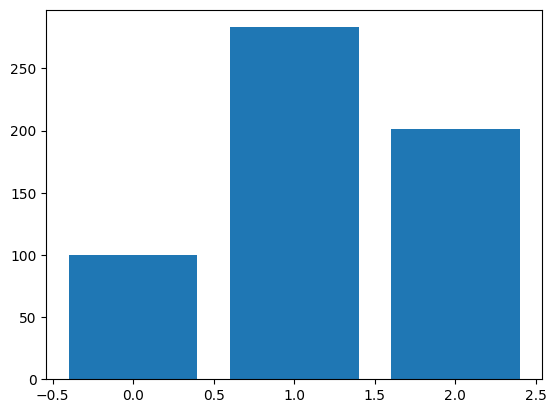

In [248]:
import matplotlib.pyplot as plt
balance = y_train.value_counts().to_frame().reset_index()
plt.bar(balance['sentiment'], height=balance['count'])

In [249]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42, replacement=False, sampling_strategy='not minority')
X_train, y_train = rus.fit_resample(X_train.to_frame(), y_train.to_frame())

<BarContainer object of 3 artists>

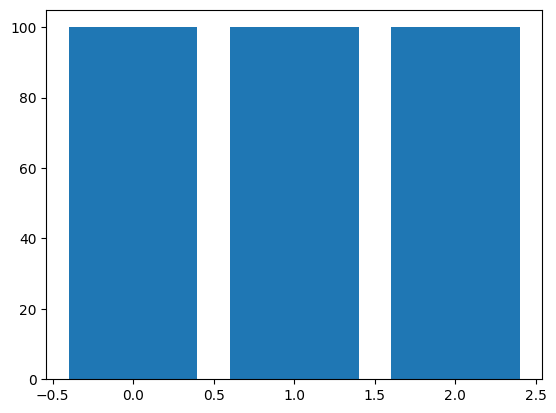

In [250]:
import matplotlib.pyplot as plt
balance = y_train.value_counts().to_frame().reset_index()
plt.bar(balance['sentiment'], height=balance['count'])

In [251]:
# Turn train data into pd.Series again...
y_train = y_train['sentiment']
X_train = X_train['cleaned_sentence']

##Step 5: Label Encoding for Sentiment Column
Encodes the categorical 'sentiment' labels into numerical format using LabelEncoder.



In [252]:
# Label Encoding for Sentiment Column
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

## Step 6: Tokenization and Padding
Tokenizes and pads the text sequences for input into a neural network using Keras's Tokenizer and pad_sequences.


In [253]:
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)
X_train_padded = pad_sequences(X_train_sequences, maxlen=100, truncating='post', padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=100, truncating='post', padding='post')

In [254]:
X_test_padded

array([[375, 466,   1, ...,   0,   0,   0],
       [734,  10,   8, ...,   0,   0,   0],
       [875,   1, 209, ...,   0,   0,   0],
       ...,
       [  1, 444,   1, ...,   0,   0,   0],
       [849,  38, 991, ...,   0,   0,   0],
       [  1,   1,   1, ...,   0,   0,   0]],
      shape=(5258, 100), dtype=int32)

In [255]:
y_test_encoded

array([1, 2, 0, ..., 1, 1, 1], shape=(5258,))

## Step 7: Transformer Model Building
Defines a Transformer model architecture using Keras. It includes an embedding layer, a Transformer block with attention mechanisms, convolutional and pooling layers, and final dense layers.


In [256]:
# Transformer Model Building
embedding_dim = 32  # We can Adjust the embedding dimension based on our preference
num_heads = 2
ff_dim = 32

inputs = Input(shape=(100,))
embedding_layer = Embedding(input_dim=10000, output_dim=embedding_dim)(inputs)
transformer_block = embedding_layer

for _ in range(num_heads):
    attn_output = Attention(use_scale=True)([transformer_block, transformer_block])
    transformer_block = LayerNormalization(epsilon=1e-6)(transformer_block + attn_output)
    transformer_block = Dropout(0.1)(transformer_block)

transformer_block = tf.keras.layers.Conv1D(filters=ff_dim, kernel_size=1, activation='relu')(transformer_block)
transformer_block = tf.keras.layers.GlobalAveragePooling1D()(transformer_block)
transformer_block = Dropout(0.1)(transformer_block)
transformer_block = Dense(20, activation='relu')(transformer_block)
output_layer = Dense(3, activation='softmax')(transformer_block)

model = Model(inputs=inputs, outputs=output_layer)

## Step 8: Model Training
Compiles and trains the Transformer model on the training data for 5 epochs.


In [257]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_padded, y_train_encoded, epochs=100, validation_data=(X_test_padded, y_test_encoded))

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.3433 - loss: 1.1113 - val_accuracy: 0.1445 - val_loss: 1.1443
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.4000 - loss: 1.0961 - val_accuracy: 0.4003 - val_loss: 1.0793
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3567 - loss: 1.0994 - val_accuracy: 0.3863 - val_loss: 1.0836
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3400 - loss: 1.0946 - val_accuracy: 0.1461 - val_loss: 1.1182
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.3767 - loss: 1.0901 - val_accuracy: 0.5409 - val_loss: 1.0740
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3400 - loss: 1.1002 - val_accuracy: 0.5384 - val_loss: 1.0795
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4200 - loss: 1.0685 - val_accuracy: 0.1455 - val_loss: 1.1362
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4800 - loss: 1.0585 - val_accuracy: 0.

##Step 9: Save the Model
Saves the trained model in the HDF5 format for future use (while developing an app and its deployment)



In [258]:
model.save('model.keras')

## Step 10: Evaluate the Model
Evaluates the model on the test set, computes accuracy, and generates a classification report.


In [259]:
y_pred_prob = model.predict(X_test_padded)

y_pred = np.array([x.argmax() for x in y_pred_prob])

print("Accuracy:", accuracy_score(y_test_encoded, y_pred))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred))

165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.5384176492963104
Classification Report:
               precision    recall  f1-score   support

           0       0.27      0.51      0.36       760
           1       0.67      0.70      0.68      2847
           2       0.53      0.27      0.36      1651

    accuracy                           0.54      5258
   macro avg       0.49      0.49      0.47      5258
weighted avg       0.57      0.54      0.53      5258



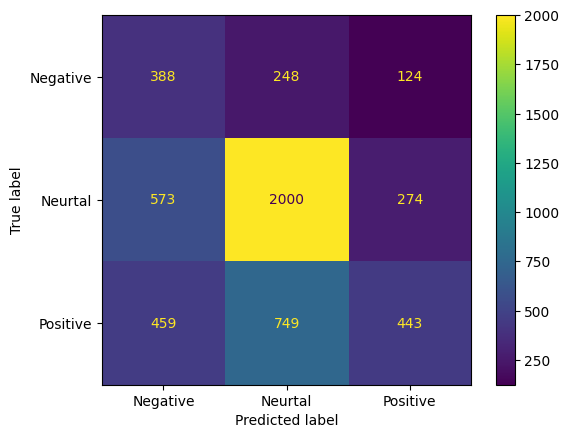

In [260]:
from sklearn import metrics
import matplotlib.pyplot as plt

confusion_matrix = metrics.confusion_matrix(y_test_encoded, y_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ['Negative', 'Neurtal', 'Positive'])
cm_display.plot()
plt.show()

## Step 11: User Input Prediction
Defines a function for predicting sentiment based on user input and prompts the user to input a review for sentiment prediction.


In [261]:
# User Input Prediction
def predict_sentiment_transformer(comment):
    labels_encoding = {
        0: 'Negative',
        1: 'Neutral', 
        2: 'Positive'
    }

    cleaned_comment = re.sub(r'[^a-zA-Z\s]', '', comment.lower())
    cleaned_comment = ' '.join(word for word in cleaned_comment.split() if word not in stop_words)
    sequence = tokenizer.texts_to_sequences([cleaned_comment])
    padded_sequence = pad_sequences(sequence, maxlen=100, truncating='post', padding='post')
    prediction = model.predict(padded_sequence)
    print(prediction)
    return labels_encoding[prediction.argmax()]

# Enter your review to get the prediction of the sentiment
user_input = input("Enter your Review here: ")
prediction = predict_sentiment_transformer(user_input)
print(f"Predicted Sentiment: {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[[0.05447218 0.90236974 0.04315801]]
Predicted Sentiment: Neutral
